# 02. Adding Wind & Curtailment

This model extends Model 01 by adding a second, independent generator to the same electrical bus.
Solar and wind rarely peak at the same time, so combining them changes both the shape of the annual
generation profile and how the plant interacts with a *limited* grid connection.

The objective is to model a standalone **10 MW Solar PV + 15 MW Wind** portfolio in the DK1 bidding
zone, sharing a single grid connection that is **smaller than their combined capacity**. This forces
the solver to make an economic curtailment decision whenever both technologies want to generate at
once: it will export as much as the grid connection allows, prioritizing whichever hours it can, and
quietly drop (curtail) the rest, since PyPSA generators are only ever capped by `p_max_pu` — never
forced to run at it.

## 🛠️ System Topology
1. **Buses:** A single primary electrical bus, same as Model 01.
2. **Generators (Source):** A solar PV plant (10 MW) and a wind plant (15 MW), each bounded by its
   own independent weather-driven capacity factor.
3. **Generators (Sink):** The grid connection, modeled exactly as in Model 01 — a generator bounded
   between -1 p.u. and 0 p.u., priced at the Day-Ahead market price, acting strictly as a sink. Its
   capacity is set to **18 MW**, below the combined 25 MW of installed solar and wind, so it can
   become a binding constraint.

Whenever the market price is positive, the solver pushes as much combined solar and wind power into
the grid sink as the 18 MW connection allows. In hours where solar and wind output together exceed
18 MW, the solver curtails the excess rather than force it through a connection that isn't there —
and it will always curtail the *cheaper-to-lose* MWh, which here means both technologies have €0
marginal cost, so the solver is indifferent between them and simply respects the physical p_max_pu
ceiling on whichever generation is in excess.

<img src="../assets/model_2.jpg" alt="Model 02 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

As in Model 01, all static technical and economic assumptions are centralized in a dictionary. Note
that `market_grid['p_nom']` is intentionally set below the combined solar and wind capacity — this
single number is what turns curtailment on or off, and is worth changing to see its effect.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'p_nom': 18.0           # Maximum export capacity to the grid (below combined RE capacity), this ensures that there will be curtailment of RE generation, which is realistic in a high RE penetration scenario
    }
}


## 🏗️ Initializing the Network

Since solar and wind both connect to the same point of common coupling and share the same grid
connection, the topology is still a single electrical bus — only the number of generators attached
to it changes.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add the single physical electrical bus
n.add("Bus", "electricity_bus")


Index(['electricity_bus'], dtype='object')

## ⚡ Adding Generators and Grid Connection

We attach both the solar PV plant and the wind plant to the same electrical bus, each with its own
weather-driven `p_max_pu` profile. The grid connection is added exactly as in Model 01 — bounded
between -1 p.u. and 0 p.u., priced at the Day-Ahead market price, acting strictly as a sink — but
sized smaller than the combined 25 MW of renewables, so it can no longer absorb everything both
generators are capable of producing at once.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Market Sink (Negative Generator)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['p_nom'],
      p_min_pu=-1.0,                        # Allows it to consume up to 100% of p_nom
      p_max_pu=0.0,                         # Prevents it from generating power
      marginal_cost=df_price['price'])      # The actual market price


Index(['Grid_Export'], dtype='object')

## 🧠 Running the Optimization

With two independent generators and one shared, capacity-limited market sink defined, the network is
passed to the solver. The solver calculates the optimal dispatch strategy for all 8760 hours
simultaneously to maximize combined revenue (minimize negative cost) — deciding, hour by hour, how
much of the available solar and wind to actually use.


In [5]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Negative Revenue): €{n.objective:,.2f}")


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 1/1 [00:00<00:00, 13.22it/s]
INFO:linopy.io: Writing time: 0.46s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26280 primals, 61320 duals
Objective: -5.05e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


Solver Status: ok
Total Objective Value (Negative Revenue): €-5,048,681.90


## 📊 Analyzing the Results

Because the grid export generator is bounded by a maximum of 0 MW and sized below the combined solar
and wind capacity, it will still export whenever the day-ahead price is positive — but only up to its
own 18 MW ceiling. Any generation beyond that, in hours where solar and wind together exceed the
connection limit, is curtailed.

To quantify this, we compare each generator's *available* power (`p_max_pu × p_nom`, what it could
have produced) against its *actual* dispatch (`n.generators_t.p`, what it was actually allowed to
produce). The difference is curtailment.


Total Annual Solar Production: 9,723.34 MWh
Total Annual Wind Production:  58,288.67 MWh
Total Annual Market Revenue:   €5,048,681.90
----------------------------------------
Solar Curtailed: 2,344.10 MWh (19.4% of available)
Wind Curtailed:  4,654.08 MWh (7.4% of available)
Total Curtailed: 6,998.18 MWh


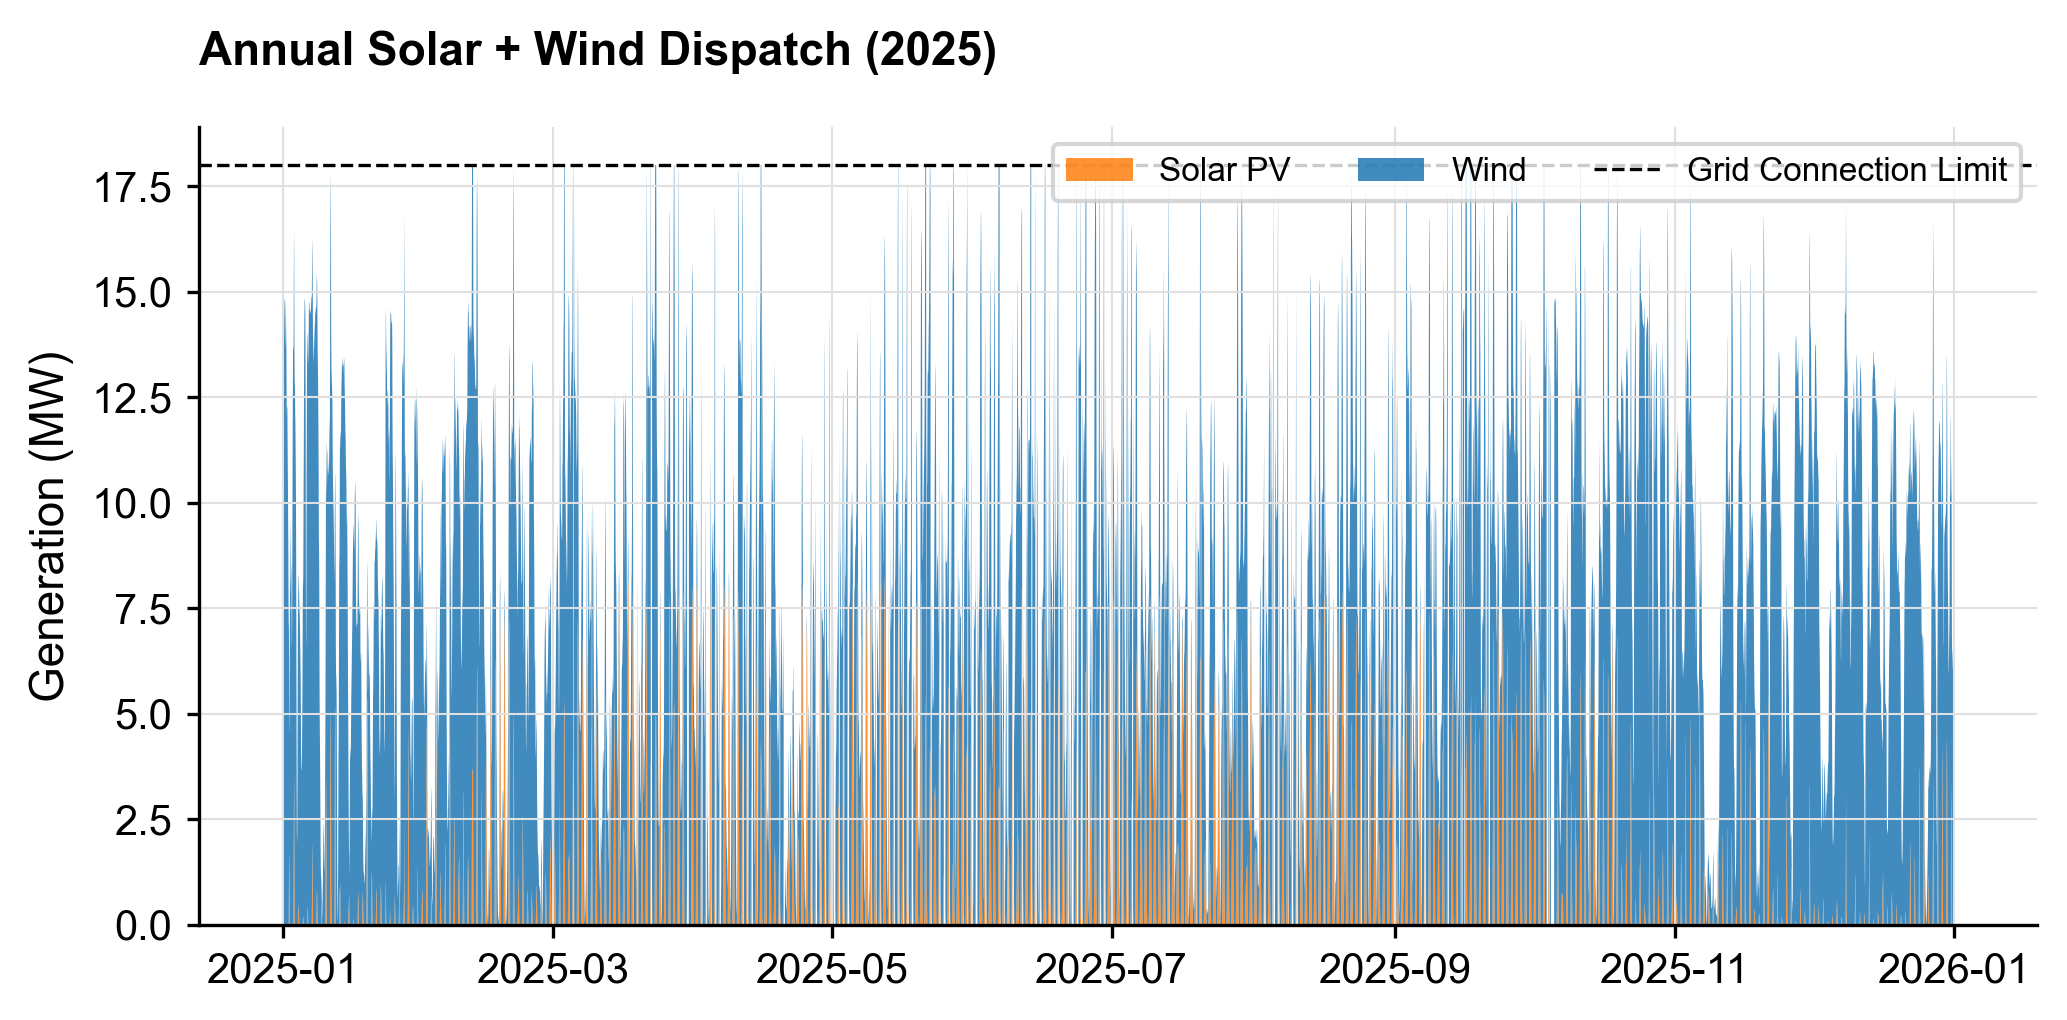

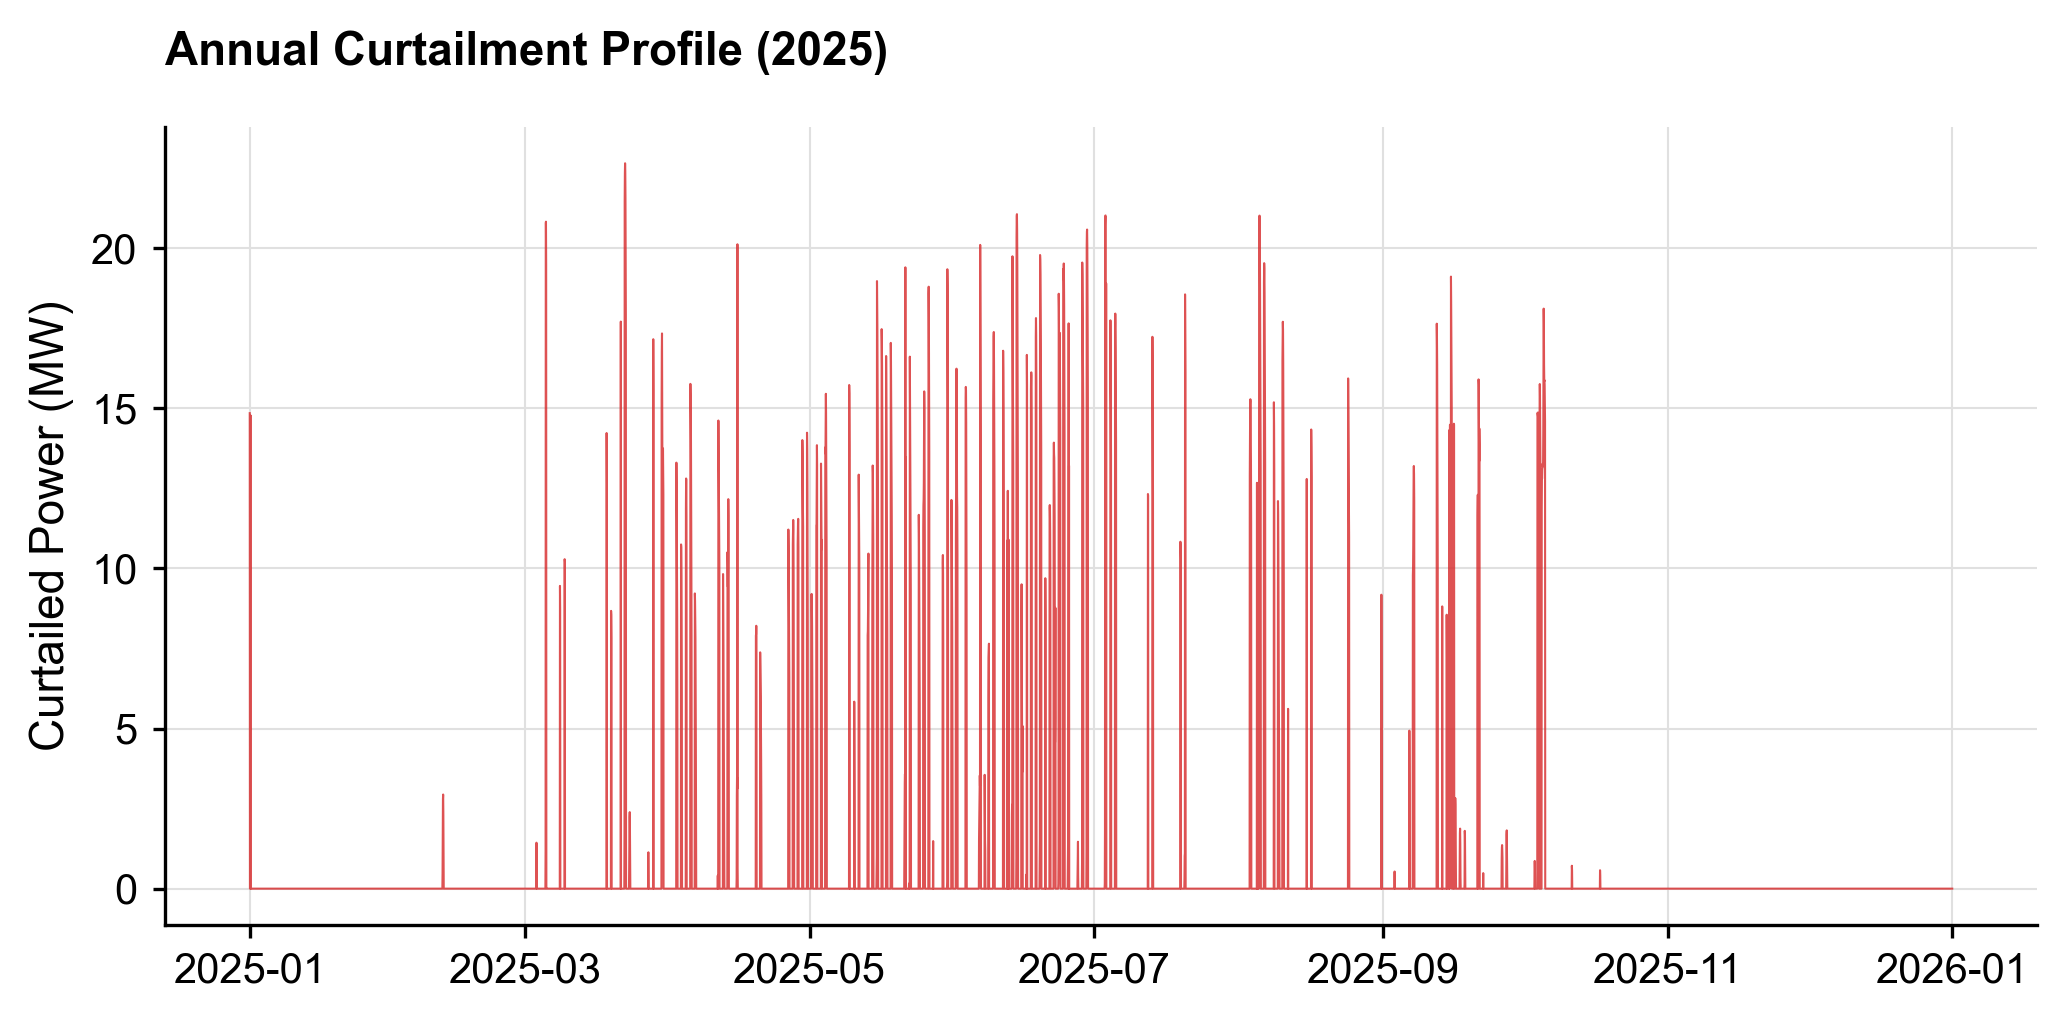

In [6]:
# Calculate Annual Totals
total_solar_mwh = n.generators_t.p['Solar_PV'].sum()
total_wind_mwh = n.generators_t.p['Wind'].sum()
total_production_mwh = total_solar_mwh + total_wind_mwh

# Because Grid_Export dispatch is a negative number, we multiply by -1 to show positive revenue
total_revenue_eur = (n.generators_t.p['Grid_Export'] * -1 * df_price['price']).sum()

# Available (uncurtailed) generation = capacity factor x nominal capacity
solar_available_mwh = (df_pv['capacity_factor'] * tech_param['solar_pv']['p_nom']).sum()
wind_available_mwh = (df_wind['capacity_factor'] * tech_param['wind']['p_nom']).sum()

solar_curtailed_mwh = solar_available_mwh - total_solar_mwh
wind_curtailed_mwh = wind_available_mwh - total_wind_mwh
total_curtailed_mwh = solar_curtailed_mwh + wind_curtailed_mwh

print(f"Total Annual Solar Production: {total_solar_mwh:,.2f} MWh")
print(f"Total Annual Wind Production:  {total_wind_mwh:,.2f} MWh")
print(f"Total Annual Market Revenue:   €{total_revenue_eur:,.2f}")
print("-" * 40)
print(f"Solar Curtailed: {solar_curtailed_mwh:,.2f} MWh ({100*solar_curtailed_mwh/solar_available_mwh:.1f}% of available)")
print(f"Wind Curtailed:  {wind_curtailed_mwh:,.2f} MWh ({100*wind_curtailed_mwh/wind_available_mwh:.1f}% of available)")
print(f"Total Curtailed: {total_curtailed_mwh:,.2f} MWh")

# Plot Annual Production Time Series (stacked solar + wind)
fig, ax = plt.subplots()

ax.stackplot(n.snapshots,
             n.generators_t.p['Solar_PV'],
             n.generators_t.p['Wind'],
             labels=['Solar PV', 'Wind'],
             colors=['#ff7f0e', '#1f77b4'], alpha=0.85)
ax.axhline(tech_param['market_grid']['p_nom'], color='black', linestyle='--', linewidth=0.8,
           label='Grid Connection Limit')

ax.set_ylabel('Generation (MW)')
ax.set_title('Annual Solar + Wind Dispatch (2025)', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

# Plot Curtailment Time Series
fig, ax = plt.subplots()

curtailment_series = (df_pv['capacity_factor'] * tech_param['solar_pv']['p_nom']
                       + df_wind['capacity_factor'] * tech_param['wind']['p_nom']
                       - n.generators_t.p['Solar_PV'] - n.generators_t.p['Wind'])

ax.plot(n.snapshots, curtailment_series, color='#d62728', alpha=0.8, linewidth=0.5)

ax.set_ylabel('Curtailed Power (MW)')
ax.set_title('Annual Curtailment Profile (2025)', pad=15, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()


## 🔍 Decomposing Curtailment: Congestion vs. Price

The curtailment equation above (`available - actual`) is correct, but it doesn't tell you
*why* curtailment happened in a given hour. In this model there are two independent causes:

1. **Congestion-driven curtailment** — combined solar + wind output exceeds the 18 MW grid
   connection limit, so the excess physically cannot be exported.
2. **Price-driven curtailment** — the Day-Ahead price is zero or negative. Since solar and
   wind both have €0 marginal cost, PyPSA is never *forced* to dispatch them at `p_max_pu`;
   it only caps them there. Exporting at a negative price would add cost (revenue turns
   negative), so the solver's cheapest option is to curtail — even if combined generation is
   well below 18 MW. This is the same mechanism described in Model 01: when price < 0, the
   grid sink shuts off and curtailment follows automatically.

The plot below splits total curtailment by hour into these two buckets so you can see which
mechanism is driving curtailment at any given time, instead of assuming it's always the
18 MW cap.

Hours curtailing due to congestion only:      111
Hours curtailing due to negative price only:   458
Hours curtailing due to both simultaneously:   63
Total curtailing hours:                        633
----------------------------------------
Total negative/zero price hours in year:       521


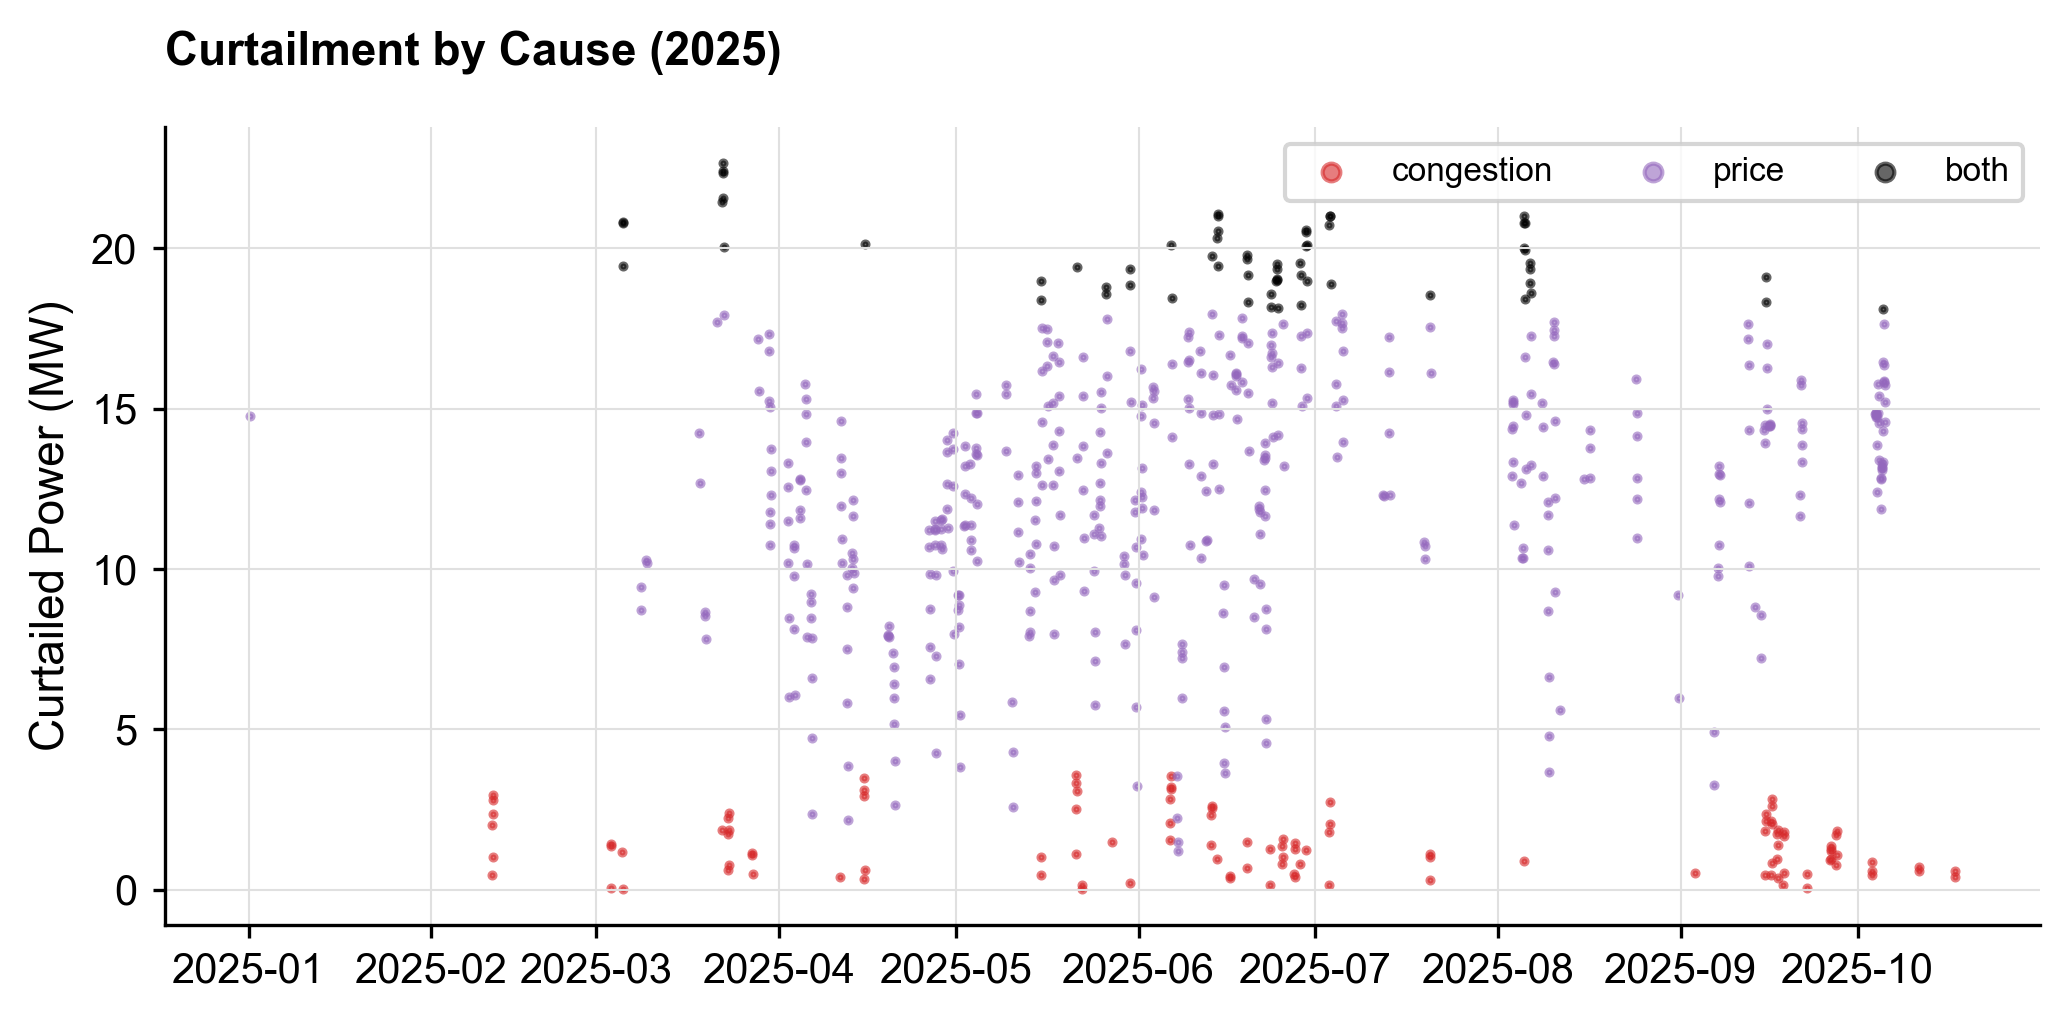

In [7]:
# Classify each hour by curtailment cause
combined_available = df_pv['capacity_factor'] * tech_param['solar_pv']['p_nom'] \
                    + df_wind['capacity_factor'] * tech_param['wind']['p_nom']

is_congested = combined_available > tech_param['market_grid']['p_nom']
is_negative_price = df_price['price'] <= 0
is_curtailing = curtailment_series > 1e-3  # numerical tolerance

congestion_only = is_curtailing & is_congested & ~is_negative_price
price_only = is_curtailing & is_negative_price & ~is_congested
both = is_curtailing & is_congested & is_negative_price

print(f"Hours curtailing due to congestion only:      {congestion_only.sum()}")
print(f"Hours curtailing due to negative price only:   {price_only.sum()}")
print(f"Hours curtailing due to both simultaneously:   {both.sum()}")
print(f"Total curtailing hours:                        {is_curtailing.sum()}")
print("-" * 40)
print(f"Total negative/zero price hours in year:       {is_negative_price.sum()}")

# Build a cause-coded curtailment series for plotting
cause = pd.Series('none', index=curtailment_series.index)
cause[congestion_only] = 'congestion'
cause[price_only] = 'price'
cause[both] = 'both'

# Plot: curtailment magnitude colored by cause
fig, ax = plt.subplots()

color_map = {'congestion': '#d62728', 'price': '#9467bd', 'both': 'black', 'none': None}
for label, c in color_map.items():
    if label == 'none':
        continue
    mask = cause == label
    ax.scatter(n.snapshots[mask], curtailment_series[mask],
               s=2, alpha=0.6, color=c, label=label)

ax.set_ylabel('Curtailed Power (MW)')
ax.set_title('Curtailment by Cause (2025)', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=3, fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()